# Epilepsy Detection with LSTM — Inference

This notebook loads the trained LSTM weights and scaler, runs inference on a new EEG sample, and plots the signal.

**Note:** `new_eeg_normal.csv` is a single unlabeled EEG sample containing 178 values, so it is used for inference rather than train/test evaluation.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
NumPy: 2.5.3
Pandas: 3.0.6


## 2. Paths

In [2]:
MODEL_DIR = "./models"
WEIGHTS_PATH = os.path.join(MODEL_DIR, "epilepsy_lstm2_weights.npz")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler2.joblib")
DATA_PATH = "new_eeg_normal.csv"

assert os.path.exists(WEIGHTS_PATH), f"Weights not found: {WEIGHTS_PATH}"
assert os.path.exists(SCALER_PATH), f"Scaler not found: {SCALER_PATH}"
assert os.path.exists(DATA_PATH), f"EEG sample not found: {DATA_PATH}"

print("Weights:", WEIGHTS_PATH)
print("Scaler:", SCALER_PATH)
print("EEG sample:", DATA_PATH)

Weights: ./models\epilepsy_lstm2_weights.npz
Scaler: ./models\scaler2.joblib
EEG sample: new_eeg_normal.csv


## 3. Rebuild the trained LSTM and load weights

In [3]:
model = Sequential([
    Input(shape=(178, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

weights_data = np.load(WEIGHTS_PATH)
weights = [weights_data[key] for key in weights_data.files]
model.set_weights(weights)
scaler = joblib.load(SCALER_PATH)

print("Loaded trained weights and scaler successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)
print("Scaler features:", getattr(scaler, "n_features_in_", "unknown"))

Loaded trained weights and scaler successfully.
Model input shape: (None, 178, 1)
Model output shape: (None, 1)
Scaler features: 178


## 4. Load the new EEG sample

In [4]:
new_sample = np.loadtxt(DATA_PATH, delimiter=",")
new_sample = np.asarray(new_sample, dtype=np.float32).reshape(1, -1)
print("Raw sample shape:", new_sample.shape)
assert new_sample.shape == (1, 178), f"Expected (1, 178), got {new_sample.shape}"

Raw sample shape: (1, 178)


## 5. Check the sample with pandas

In [5]:
df = pd.read_csv(DATA_PATH, header=None)
print("DataFrame shape:", df.shape)
display(df.head())
assert df.shape == (1, 178), f"Expected (1, 178), got {df.shape}"

DataFrame shape: (1, 178)


,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
0,-86,-101,-115,-129,-139,-147,-154,-159,-165,-170,...,-33,-39,-43,-44,-45,-39,-38,-35,-34,-36


## 6. Predict on the new EEG sample

In [6]:
def predict_new_eeg(file_path, model, scaler):
    signal = np.loadtxt(file_path, delimiter=",")
    signal = np.asarray(signal, dtype=np.float32).reshape(1, -1)
    if signal.shape != (1, 178):
        raise ValueError(f"Expected one EEG sample with 178 values; got {signal.shape}")
    scaled = scaler.transform(signal)
    sequence = scaled.reshape(1, 178, 1)
    prob = float(model.predict(sequence, verbose=0).ravel()[0])
    pred = int(prob >= 0.5)
    print(f"Prediction Probability: {prob:.4f}")
    print("Result: Epileptic" if pred == 1 else "Result: Not Epileptic")
    return prob, pred

prob, pred = predict_new_eeg(DATA_PATH, model, scaler)

Prediction Probability: 0.0229
Result: Not Epileptic


## 7. Plot the EEG waveform

Prediction Probability: 0.0229
Result: Not Epileptic


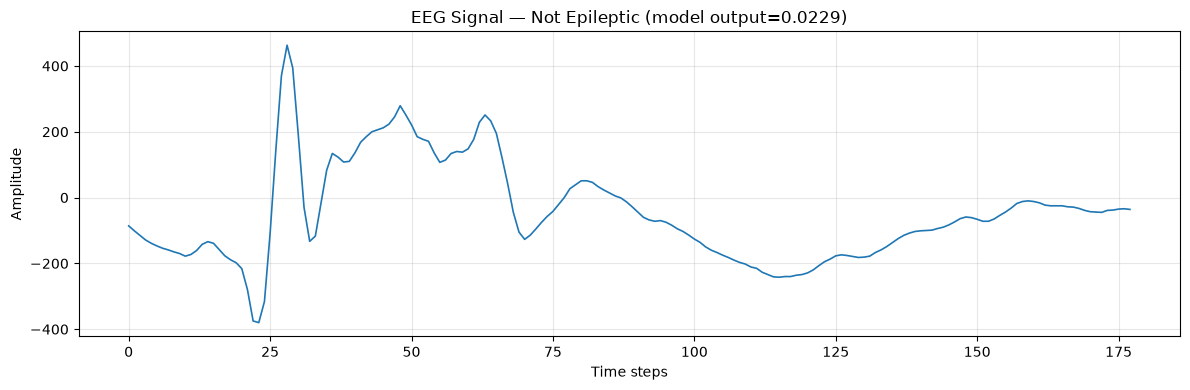

In [7]:
def plot_eeg(file_path, model, scaler):
    signal = np.loadtxt(file_path, delimiter=",").reshape(-1)
    prob, pred = predict_new_eeg(file_path, model, scaler)
    plt.figure(figsize=(12, 4))
    plt.plot(signal, linewidth=1.2)
    plt.title(f"EEG Signal — {'Epileptic' if pred == 1 else 'Not Epileptic'} (model output={prob:.4f})")
    plt.xlabel("Time steps")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_eeg(DATA_PATH, model, scaler)

## 8. Summary

- Input: one EEG sample with 178 values.
- Preprocessing: `scaler2.joblib` is applied before reshaping to `(1, 178, 1)`.
- Model: LSTM architecture reconstructed from the saved weights.
- Decision threshold: `0.5`.
- Class `1` should be interpreted as epileptic only according to the label mapping established during training.

NameError: name 'X_val_seq' is not defined